Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Generate Synthetic Dataset

In [2]:
np.random.seed(42)

In [3]:
n = 100000

In [4]:
df = pd.DataFrame({
    "Customer_ID": np.arange(1, n+1),
    "Age": np.random.randint(18, 71, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Tenure": np.random.randint(0, 11, n),
    "Balance": np.random.randint(0, 200001, n),
    "CreditScore": np.random.randint(300, 901, n),
    "EstimatedSalary": np.random.randint(10000, 150001, n),
    "NumOfProducts": np.random.randint(1, 5, n),
    "IsActiveMember": np.random.choice(["Yes", "No"], n),
    "Churn": np.random.choice([0, 1], n, p=[0.7, 0.3])
})

In [5]:
print(df.head())

   Customer_ID  Age  Gender  Tenure  Balance  CreditScore  EstimatedSalary  \
0            1   56  Female       3   138803          718           121992   
1            2   69    Male       1   174102          534           125877   
2            3   46  Female      10    90135          653            39062   
3            4   32    Male       6   160284          787            66364   
4            5   60  Female       6    24298          681           116045   

   NumOfProducts IsActiveMember  Churn  
0              4             No      0  
1              2             No      0  
2              2            Yes      0  
3              2            Yes      0  
4              2            Yes      1  


Data Cleaning & Preprocessing

In [6]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64


In [7]:
print("\nData Types:\n", df.dtypes)


Data Types:
 Customer_ID         int64
Age                 int64
Gender             object
Tenure              int64
Balance             int64
CreditScore         int64
EstimatedSalary     int64
NumOfProducts       int64
IsActiveMember     object
Churn               int64
dtype: object


In [8]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["IsActiveMember"] = df["IsActiveMember"].map({"No": 0, "Yes": 1})

Descriptive Statistics

In [9]:
print("\nMean:\n", df.mean(numeric_only=True))


Mean:
 Customer_ID        50000.50000
Age                   43.98406
Gender                 0.49891
Tenure                 4.98876
Balance            99742.23367
CreditScore          599.94275
EstimatedSalary    79959.02136
NumOfProducts          2.50198
IsActiveMember         0.49893
Churn                  0.30074
dtype: float64


In [10]:
print("\nMedian:\n", df.median(numeric_only=True))


Median:
 Customer_ID        50000.5
Age                   44.0
Gender                 0.0
Tenure                 5.0
Balance            99729.0
CreditScore          599.0
EstimatedSalary    80008.5
NumOfProducts          3.0
IsActiveMember         0.0
Churn                  0.0
dtype: float64


In [11]:
print("\nMode:\n", df.mode().iloc[0])


Mode:
 Customer_ID            1.0
Age                   40.0
Gender                 0.0
Tenure                 4.0
Balance            67150.0
CreditScore          521.0
EstimatedSalary    11429.0
NumOfProducts          3.0
IsActiveMember         0.0
Churn                  0.0
Name: 0, dtype: float64


In [12]:
print("\nStandard Deviation:\n", df.std(numeric_only=True))


Standard Deviation:
 Customer_ID        28867.657797
Age                   15.251827
Gender                 0.500001
Tenure                 3.163744
Balance            57670.541911
CreditScore          173.269555
EstimatedSalary    40445.277417
NumOfProducts          1.117734
IsActiveMember         0.500001
Churn                  0.458582
dtype: float64


Churn Analysis

In [13]:
print("\nChurn Count:\n", df["Churn"].value_counts())


Churn Count:
 Churn
0    69926
1    30074
Name: count, dtype: int64


In [14]:
print("\nChurn Percentage:\n", df["Churn"].value_counts(normalize=True)*100)


Churn Percentage:
 Churn
0    69.926
1    30.074
Name: proportion, dtype: float64


Group-Based Analysis

In [15]:
print("\nGender vs Churn:\n", df.groupby("Gender")["Churn"].mean())


Gender vs Churn:
 Gender
0    0.303798
1    0.297669
Name: Churn, dtype: float64


In [16]:
print("\nActive vs Churn:\n", df.groupby("IsActiveMember")["Churn"].mean())


Active vs Churn:
 IsActiveMember
0    0.299160
1    0.302327
Name: Churn, dtype: float64


In [17]:
print("\nProducts vs Churn:\n", df.groupby("NumOfProducts")["Churn"].mean())


Products vs Churn:
 NumOfProducts
1    0.300116
2    0.301599
3    0.301711
4    0.299533
Name: Churn, dtype: float64


In [18]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[18,25,35,50,70],
                       labels=["18-25","26-35","36-50","50+"])

In [19]:
print("\nAge Group vs Churn:\n", df.groupby("AgeGroup")["Churn"].mean())


Age Group vs Churn:
 AgeGroup
18-25    0.306786
26-35    0.303474
36-50    0.297474
50+      0.299705
Name: Churn, dtype: float64


/tmp/ipykernel_6498/1494877233.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("\nAge Group vs Churn:\n", df.groupby("AgeGroup")["Churn"].mean())


Relationship Analysis

In [20]:
print("\nCorrelation:\n", df.corr(numeric_only=True))


Correlation:
                  Customer_ID       Age    Gender    Tenure   Balance  \
Customer_ID         1.000000 -0.000359  0.003538  0.004342 -0.000222   
Age                -0.000359  1.000000  0.001048 -0.000486 -0.002837   
Gender              0.003538  0.001048  1.000000 -0.000981 -0.003567   
Tenure              0.004342 -0.000486 -0.000981  1.000000  0.001169   
Balance            -0.000222 -0.002837 -0.003567  0.001169  1.000000   
CreditScore        -0.005602 -0.002580 -0.002401 -0.006829 -0.001880   
EstimatedSalary    -0.002574 -0.001827 -0.001989  0.003423  0.002050   
NumOfProducts      -0.002040 -0.003039  0.000371  0.000747 -0.002238   
IsActiveMember     -0.005706 -0.001007 -0.001245 -0.004641 -0.000833   
Churn              -0.001794 -0.004503 -0.006682 -0.004446 -0.001607   

                 CreditScore  EstimatedSalary  NumOfProducts  IsActiveMember  \
Customer_ID        -0.005602        -0.002574      -0.002040       -0.005706   
Age                -0.002580    

Data Visualization

Bar Plot

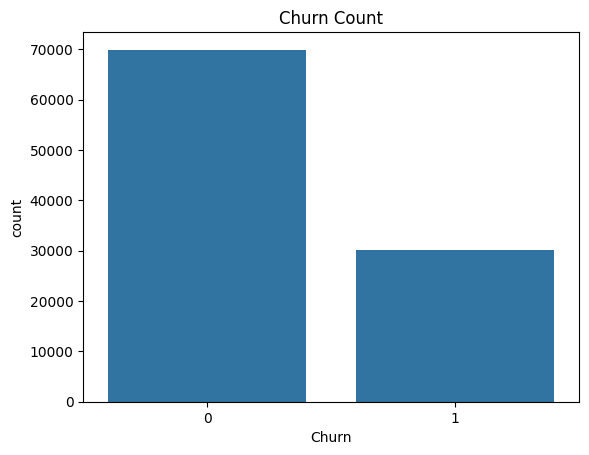

In [21]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Count")
plt.show()

Pie Chart

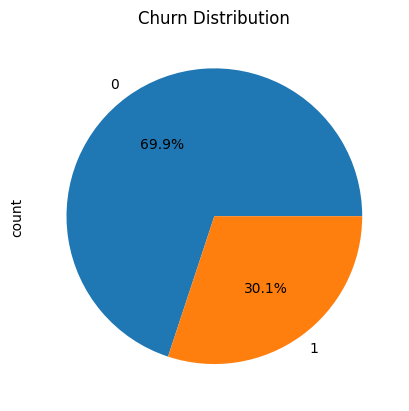

In [22]:
df["Churn"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Churn Distribution")
plt.show()

Histogram

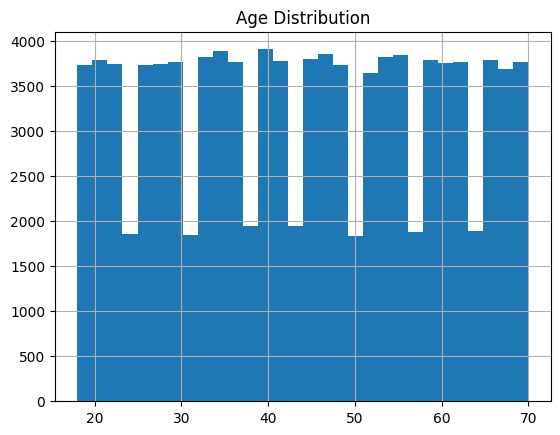

In [23]:
df["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.show()

Box Plot

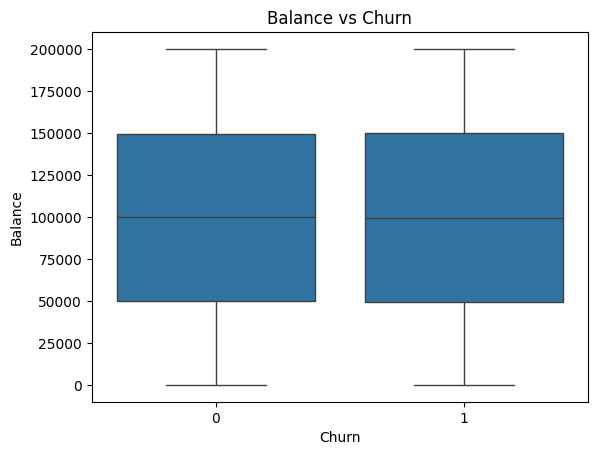

In [24]:
sns.boxplot(x="Churn", y="Balance", data=df)
plt.title("Balance vs Churn")
plt.show()

Scatter Plot

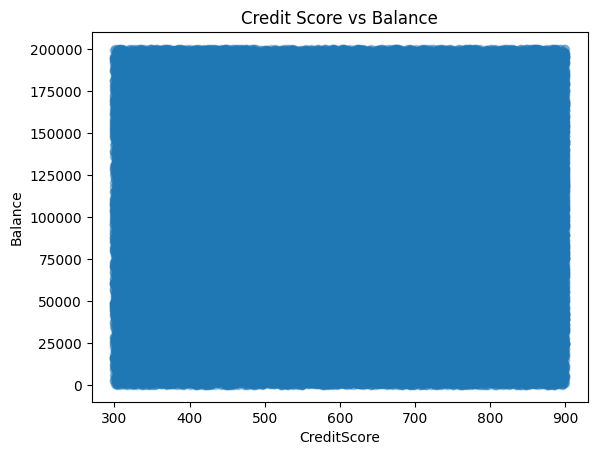

In [25]:
plt.scatter(df["CreditScore"], df["Balance"], alpha=0.3)
plt.title("Credit Score vs Balance")
plt.xlabel("CreditScore")
plt.ylabel("Balance")
plt.show()

Heatmap

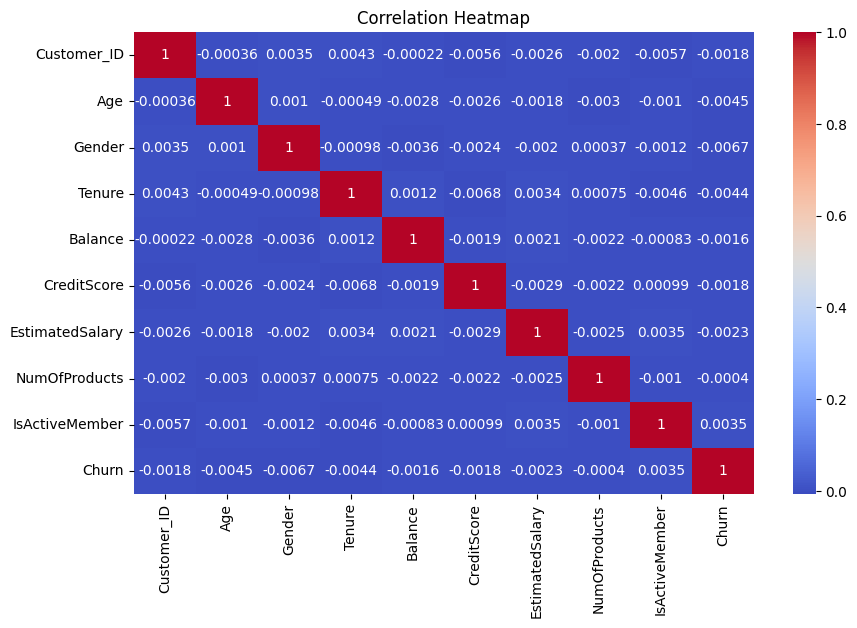

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()